# Colab 환경에서 실행 시 환경 설정

구글 드라이브의 폴더와 구글 코랩 폴더 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 현재 경로 확인
!pwd

In [ ]:
# drive/MyDrive/Colab Notebooks 경로로 변경
%cd drive/MyDrive/'Colab Notebooks'

### 코랩에서 한국어 표시하기

In [ ]:
%pip install koreanize-matplotlib

In [36]:
import koreanize_matplotlib

# 🔖 제목

<a id="lecture_index"></a>
# 수업 목차 

[1. 복습](#one)<br>

[2. 자연어 처리 개요](#two)<br>
- 자연어 처리란?
- 자연어 처리의 발전 흐름
- 자연어 처리 작업 분류

[3. 자연어 데이터의 특징 및 처리 과정](#three)<br>
- 자연어 데이터란? 
- 텍스트 데이터의 특징 
- 텍스트 데이터의 처리 과정

[4. 규칙기반 자연어 처리](#four)<br>
- 형태소 분석 
- 토큰화
- 정규화 
- 불용어 제거 
- 표제어 추출 
- 어간 추출 
- 규칙 기반 NLP의 활용

[5. 통계기반 자연어 처리](#five)<br>
- 코퍼스 기반 통계 개념
- Bag of Words
- TF-IDF

[6. 분산표현과 신경망](#six)<br>
- 워드 임베딩의 개념 
- Word2Vec

# <a id='one'>1️⃣ 복습</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

# <a id='two'>2️⃣ 자연어 개요</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 자연어 처리란?

> 자연어 처리(Natural Language Processing, NLP)는 컴퓨터가 인간의 언어를 이해하고 처리하는 기술 <br>

### 자연어 처리의 발전 흐름

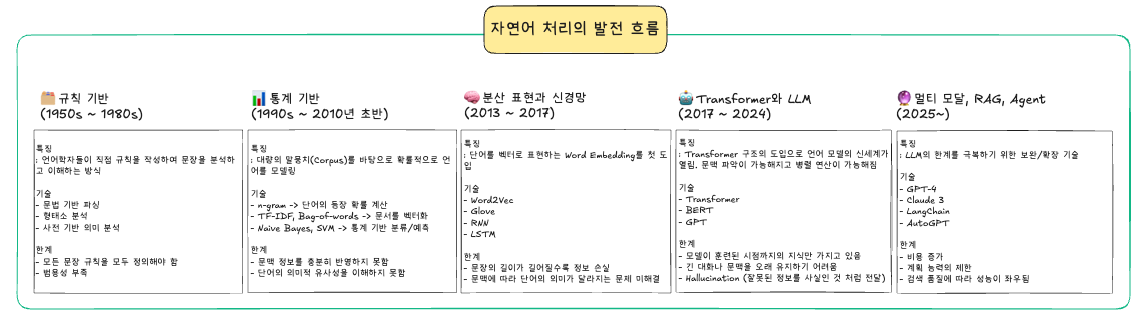

### ✅ 규칙 기반 

#### 👍 장점: 특정한 문제에 대해 높은 정확도 가능
#### 👎 단점: 노가다, 일반화 불가능, 순차성, 문맥이해, 단어의 유사성 이해 X 

### ✅ 통계 기반 

#### 👍 장점: 규칙을 직접 설계할 필요 없음 (처음으로 데이터 기반으로 처리가 가능해짐)
#### 👎 단점: 단어간에 의미적 유사성을 표현하지 못함, 순차성, 맥락 이해 부족

### ✅ 분산 표현 기반 

#### 👍 장점: 단어간의 의미적 유사성 표현 가능 
#### 👎 단점: 문맥이해, 순차성 부족 

### ✅ 딥러닝 기반 

#### 👍 장점: 순차적 데이터 처리 가능, 맥락 파악 일부 가능 
#### 👎 단점: 글 전체적인 흐름 파악 부족, 병렬 처리 어려움 

### ✅ LLM  

#### 👍 장점: 전체 문장의 흐름, 맥락 파악 가능 
#### 👎 단점: Hallucination, 학습한 데이터 내에서 답변 가능

### 자연어 처리 작업 분류

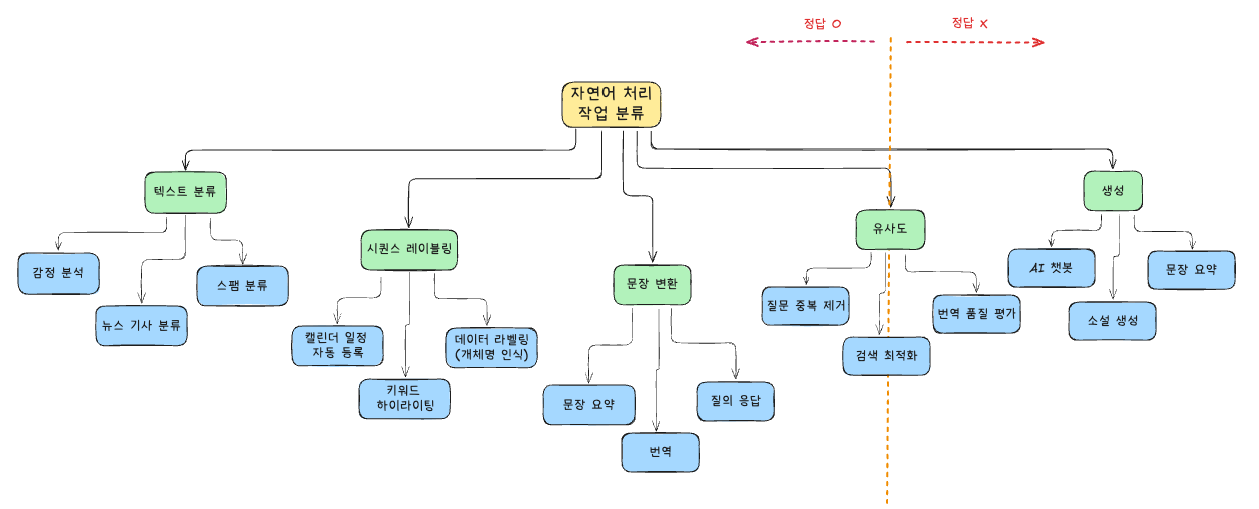

# <a id='three'>3️⃣ 자연어 데이터의 특징 및 구조</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 3-1) 자연어 데이터란? 
> 사람이 일상생활에서 사용하는 언어. <br>
> 자연어 데이터에는 크게 두 가지 형태로 존재함. 1. 텍스트 2. 음성 <br> 
> 예) 한국어, 영어, 일본어, 중국어, 스페인어 등..

### 텍스트 데이터

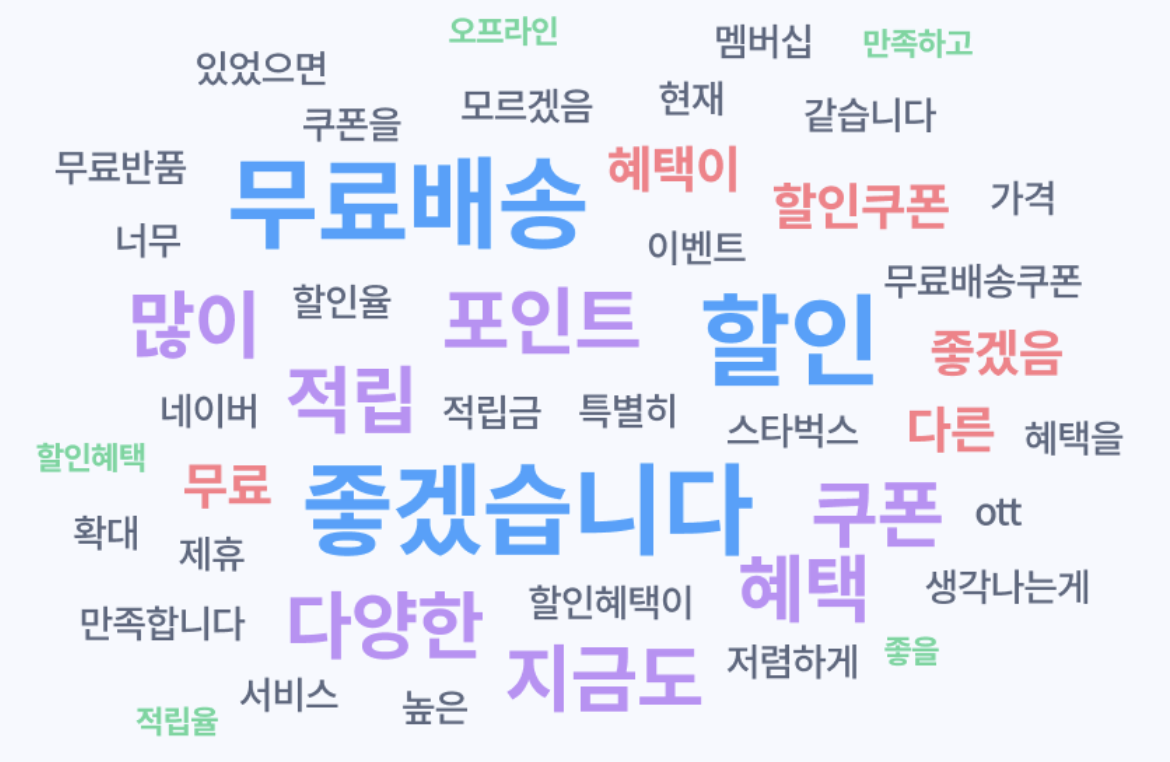

### 음성 데이터

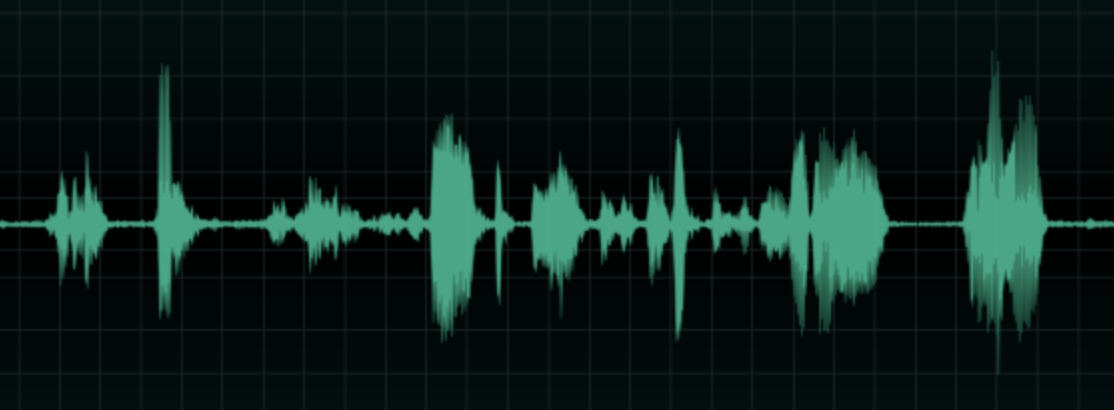

##### 👉 음성 데이터의 형태는 텍스트가 아니라 소리이기 때문에 '파형' 형태를 띈다

### 💡 NLP라는 기술은 텍스트 데이터를 컴퓨터가 이해하고 생성하고 응답하도록 만드는 기술!

## 3-2) 텍스트 데이터의 특징

### 형태

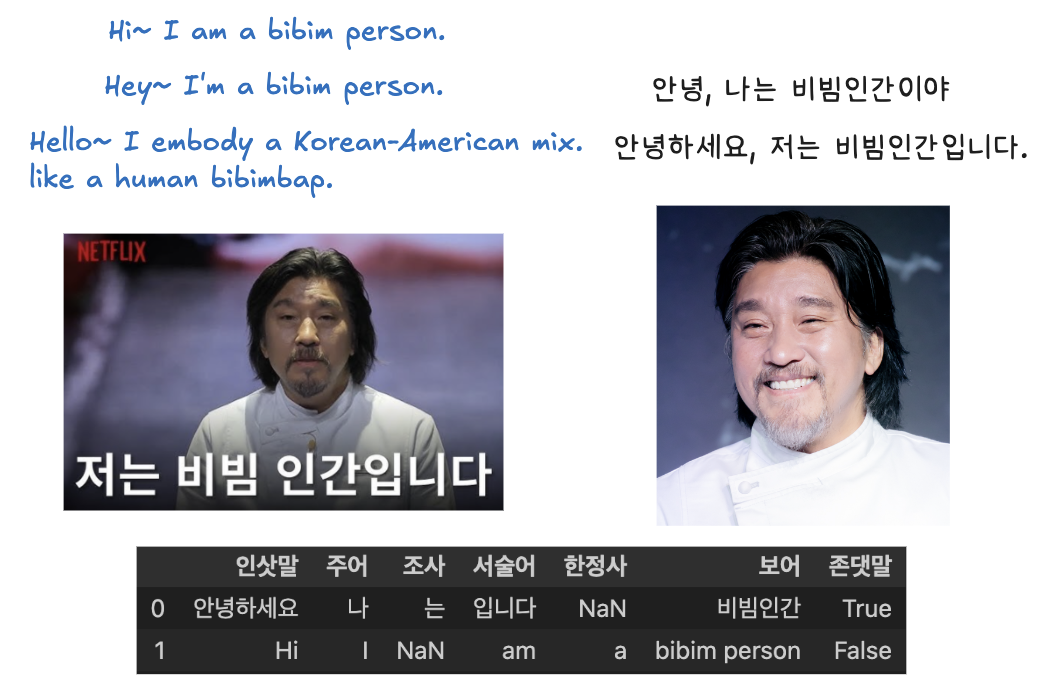

### ① 비정형 데이터 
- 테이블 데이터와 다르게 형식이 없음
- 전처리와 정형화 과정이 필수적

### ② 모호성 
- 같은 단어라도 상황에 따라 의미가 달라짐
- 동음이의어, 다의어, 문맥 의존성이 존재함 

### ③ 다양한 표현 방식 
- 같은 의미도 여러 가지 표현 가능 
- 동의어, 의미적 유사성 인식이 필요 

### ④ 순차성 
- 단어의 순서가 중요함 
- 순서가 의미에 큰 영향을 주기 때문에 시계열 데이터 처럼 다뤄야 함 

### ⑤ 고차원 + 희소성   -> Sparsity
- 단어를 벡터로 표현하면, 단어 수만큼 차원이 생김 (단어 하나당 하나의 차원으로 표현)
- 예) 단어 사전이 10,000개면 모든 문장은 10,000차원 벡터로 표현
- 한 문장 안에는 그렇게 많은 단어로 이루어져 있지 않음 
- 예) 한 문장이 10개 단어로 이루어져 있고, 단어 사전이 10,000개라면 9990개는 0으로 채워지고 10개만 값을 가짐 

### ⑥ 문맥 의존성 
- 단어의 의미는 주변 단어에 따라 달라짐 
- 예) 나는 배가 아파서 병원에 갔다 -> 여기서 '배'는 사람의 신체부위 

### ⑦ 언어별 차이
- 언어별로 어순이 다르고 표현하는 글자가 다름 
- 한국어의 경우 형태소 분리가 중요함 
- 예) 먹었습니다 -> 먹/었/습니다 

## 3-3) 텍스트 데이터 처리 과정

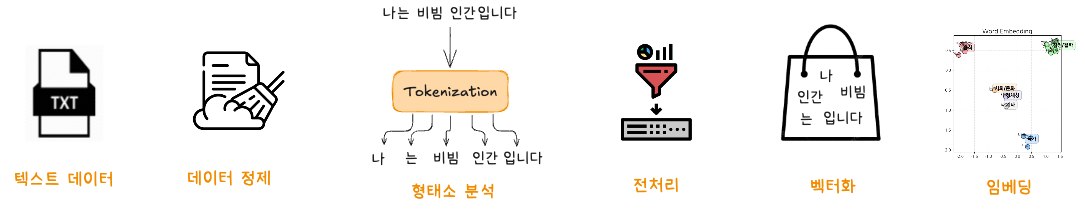

# <a id='four'>4️⃣ 규칙기반 자연어 처리</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 형태소 분석 및 전처리

> 목적: 기계가 문장 안에 어떤 정보가 들어 있는지 이해할 수 있도록 '의미 있는 단어를 추출'

라이브러리|분석기 이름|특징|설치 난이도|
---|---|---|---
KoNLPy|Okt(트위터), Kkma, Hannanum, Komoran, Mecab| 파이썬 인터페이스 지원, 다양한 분석기 통합 제공|⭐️⭐️⭐️⭐️
Mecab|Mecab|매우 빠르고 정확도가 높음. 특히 대용량 텍스트 처리에 적합, 언어 사전 커스터마이징 가능|⭐️⭐️

분석기 이름|개발 기관|속도|정확도|복합어 처리|구어체 처리|신조어 처리
---|---|---|---|---|---|---
Okt|트위터->은전한닢|⭐️⭐️⭐️|⭐️⭐️|⭐️⭐️⭐️|⭐️⭐️⭐️⭐️⭐️|⭐️⭐️⭐️⭐️
Kkma|서울대학교|⭐️|⭐️⭐️⭐️⭐️|⭐️⭐️⭐️⭐️⭐️|⭐️|⭐️
Hannanum|KAIST|⭐️⭐️|⭐️⭐️|⭐️|⭐️|⭐️
Komoran|Shineware|⭐️⭐️⭐️⭐️|⭐️⭐️⭐️|⭐️⭐️⭐️⭐️|⭐️⭐️|⭐️⭐️
Mecab(KoNLPy)|일본 도쿄대 연구원->은전한닢|⭐️⭐️⭐️⭐️⭐️|⭐️⭐️⭐️⭐️|⭐️⭐️⭐️⭐️⭐️|⭐️⭐️|⭐️

In [10]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
%pip install Korpora

In [1]:
# konlpy 설치하기 전 필요한 설치 
# Java 1.8 버전 이상 설치 (java version "1.8.0_441") https://www.oracle.com/java/technologies/downloads/#jdk21-mac
# jpype1 설치 (1.4.1 버전 이상)
# konlpy 설치 (0.6.0 버전 이상)
import konlpy 
from konlpy.tag import Okt, Kkma, Hannanum, Komoran, Mecab

In [ ]:
okt = Okt() # 대문자로 시작하는 것 -> 대부분 클래스 / 실행 또는 활용 하려면 -> 인스턴스화 (클래그에서 객체를 만드는 행위)

In [45]:
korean_text = "요즘 날씨가 좋다 ㅎㅎㅎㅎㅎㅎㅎ"
morphs = okt.morphs(korean_text) # 형태소 추출 
morphs_pos = okt.pos(korean_text) # 형태소 + 품사 태그 반환 (pos: part of speech)
headword = okt.pos(korean_text, stem=True) # 표제어 추출
nouns = okt.nouns(korean_text) # 명사 추출 
            # norm = normalization => 반복되는 단어를 일정하게 만들어 준다 / stem => 어간 추출
norm = okt.morphs(korean_text, norm=True, stem=True) # 문장 속 줄임말/이모티콘 등 정규화된 표현으로 바꿔줌 
phrases = okt.phrases(korean_text) # 문장을 어절 단위로 추출 (구어체 분석에서 사용)
okt.tagset # 품사 태그 체계 조회용

{'Adjective': '형용사',
 'Adverb': '부사',
 'Alpha': '알파벳',
 'Conjunction': '접속사',
 'Determiner': '관형사',
 'Eomi': '어미',
 'Exclamation': '감탄사',
 'Foreign': '외국어, 한자 및 기타기호',
 'Hashtag': '트위터 해쉬태그',
 'Josa': '조사',
 'KoreanParticle': '(ex: ㅋㅋ)',
 'Noun': '명사',
 'Number': '숫자',
 'PreEomi': '선어말어미',
 'Punctuation': '구두점',
 'ScreenName': '트위터 아이디',
 'Suffix': '접미사',
 'Unknown': '미등록어',
 'Verb': '동사'}

In [55]:
norm

['요즘', '날씨', '가', '좋다', 'ㅎㅎㅎ']

### 🏷 Hannanum 형태소 태그 정리표

| 태그   | 설명                                | 예시                     |
|--------|-------------------------------------|--------------------------|
| **ncps** | 일반 명사 (단수형)                  | 안녕                     |
| **ncpa** | 행위 명사 (동작 관련 명사)          | 공부                     |
| **npp**  | 대명사                              | 저                       |
| **ncn**  | 일반 명사                           | 인공지능, 요, 재미       |
| **xsms** | 보조용언 어간 (동사)                | 하 (하다의 어간)         |
| **xsva** | 보조용언 어간 (형용사)              | 하 (공부하+고)           |
| **xsmn** | 보조용언 어간 (명사형)              | 있 (재미있어요)          |
| **ecc**  | 연결 어미 (보조적 연결)             | 고 (공부하고)            |
| **ecs**  | 연결 어미 (계속적 연결)             | 고                       |
| **ecx**  | 연결 어미 (혼합형)                  | 고                       |
| **jxc**  | 보조사                              | 는                       |
| **jco**  | 목적격 조사                         | 을                       |
| **ef**   | 종결 어미                           | 어요, 세요               |
| **jxf**  | 종결 보조사                         | 요                       |
| **sf**   | 마침표/느낌표 등 구두점            | ., !                     |
| **sy**   | 기호                                | .                        |
| **jcj**  | 접속 조사                           | 하고                     |
| **jct**  | 시간 연결 조사                      | 하고                     |
| **jcr**  | 이유 연결 조사                      | 고                       |
| **paa**  | 상태 서술 형용사                    | 있                       |
| **px**   | 보조 용언                           | 있                       |
| **pvg**  | 일반 동사                           | 재미있                   |
| **f**    | 외국어 (Foreign)                    | NLP                      |

### 전처리 
> 같은 단어는 같다고 이해할 수 있게, 다른건 다르게 이해할 수 있게 변환 하는 작업. <br> 
> 문장을 이해하는데 방해가 되는 불필요한 단어를 제거하기도 한다

- 불용어 처리
- 표제어 추출
- 어간 추출
- 정규화

colab 사용시 아래 실행

In [ ]:
# !git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git

In [ ]:
# %cd Mecab-ko-for-Google-Colab/

In [ ]:
# !bash install_mecab-ko_on_colab_light_220429.sh

In [1]:
from konlpy.tag import Mecab

mecab = Mecab()

Exception: Install MeCab in order to use it: http://konlpy.org/en/latest/install/

In [2]:
def preprocess(text, stoptags, stopwords):
    result = []
    
    words = mecab.pos(text)
    for word_pos in words:
        if word_pos[1] in stoptags:
            continue
        elif word_pos[0] in stopwords:
            continue
        
    return set(result)

In [ ]:
for word in preprocess(text, stoptag, stopword):
    

불용어 처리

In [60]:
# 불용어 품사 목록 (J: 조사, E: 어미, X: 접사, S: 기호, SF: 마침표, 물음표, 느낌표, SE: 줄임표, SSO: 여는 괄호, SSC: 닫는 괄호, SY: 기타 기호, SC: 구분자)
stoptags = ["J", "E", "X", "S", "SF", "SE", "SSO", "SSC", "SY", "SC"]

# 불용어 단어 목록 (원한다면 직접 추가)
stopwords = ["은", "는", "이", "가", "을", "를", "에", "의", "도", "다", "하고", "입니다", "그리고"]

#### 정규화
> 목적: 문장 내에 다양한 표현 방식을 통일된 형태로 바꾸기 위해 <br>
> 효과: 비슷한 표현은 동일한 벡터로 처리하여 복잡도를 낮춘다 <br> 
> 상황: 감성 분석, 키워드 추출, 문서 분류, 신조어, 축약어, 비표준 표현 통합 

In [15]:
import re   # 정규표현식을 사용하기 위한 모듈
from konlpy.tag import Okt
okt = Okt()

text = "ㅋㅋㅋㅋㅋㅋㅋ 개좋다 짱맛탱~~~"

In [18]:
re.sub(r'(\b[가-힣]+)\1+', r'\1', okt.morphs(text))

TypeError: expected string or bytes-like object

#### 어간 추출 
> 목적: 단어에서 접사, 어미 등 부가적인 부분을 제거하고 핵심 어간만 남기는 작업 <br> 
> 효과: 다양한 활용형을 하나의 어간으로 통일함으로써 <br> 
> 상황: 감성 분석, 키워드 추출, 문서 분류 

In [ ]:
tokens = okt.morphs("감동적이었다", stem=True)
print(tokens)

['감동', '적', '이다']


#### 표제어 추출 
> 목적: 정확한 문법 기반의 단어로 바꾸는 작업 <br> 
> 효과: 정확한 단어의 형태를 유지하여 의미를 보존한다 <br> 
> 상황: 번역, 질의 응답, 요약 등 정확한 의미 분석

In [20]:
from nltk.stem import WordNetLemmatizer # 영어 WordNet 사전 기반이라 한국어 처리 능력이 없음 

lemmatizer = WordNetLemmatizer()

In [22]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\human\AppData\Roaming\nltk_data...


True

In [28]:
lemmatizer.lemmatize("better", pos='a')  # good

'good'

### 감성 분석 (긍정/부정 단어 사전 기반)

In [33]:
positive_words = ["좋다", "감동", "행복", "재밌다", "사랑"]
negative_words = ["별로", "싫다", "지루", "실망", "짜증"]

In [65]:
def testing(text, positive, negative):
    count = 0
    
    datas = okt.morphs(text, norm=True, stem=True)
    print(datas)
    for data in datas:
        if data in positive:
            count += 1
        elif data in negative:
            count -= 1
            
    return '긍정' if count > 0 else '부정' if count < 0 else '중립'

In [57]:
text1 = '나 오늘 너무 행복해'
text2 = '아 너 정말 실망이야. 근데 사랑해'
text3 = '너 진짜 별로다. 실망이야.'

In [66]:
print(testing(text1, positive_words, negative_words))
print(testing(text2, positive_words, negative_words))
print(testing(text3, positive_words, negative_words))

['나', '오늘', '너무', '행복하다']
중립
['아', '너', '정말', '실망', '이야', '.', '근데', '사랑', '하다']
중립
['너', '진짜', '별로', '다', '.', '실망', '이야', '.']
부정


### 유사한 문장 판별

### 키워드 추출

## 🧩 Quiz 3

#### 다음 중 규칙 기반 자연어 처리 방식의 활용 예로 적절하지 않은 것은?

```
A. 한글에서 조사(“을”, “를”)를 분리하여 의미 있는 어절을 추출하는 형태소 분석기 개발
B. 의학 도메인에서 사전에 정의된 약어와 전문 용어 사전을 기반으로 임상 기록에서 개체명을 추출하는 시스템
C. 온라인 리뷰에서 ‘재미없다’, ‘별로였다’ 등의 감정을 학습 데이터를 기반으로 자동 분류하는 감성 분석 시스템
D. 특수 기호, 반복 문자, 이모티콘 등을 정규식을 활용하여 제거하는 텍스트 정제기
E. 직접 설계한 문법 규칙으로 날짜 표현을 인식하고 표준화하는 규칙 기반 날짜 인식기
F. 규칙적으로 정의된 이메일 주소, 전화번호 등의 패턴을 정규표현식으로 탐지하고 정제하는 텍스트 필터
G. 뉴스 기사에서 감정이 강하게 나타나는 표현(“충격”, “최악”, “완벽”)의 빈도 수 기반으로 긍/부정을 분류하는 모델
```

#### 다음 문장을 형태소 분석기(tokenizer)를 활용하여 아래 결과 처럼 나오도록 처리하시오

```
분석전: "진짜진짜 이 영화는 너무 너무 별로였어요 ㅠㅠㅠㅠㅠ"
분석후: ['진짜', '영화', '별로', '이다', 'ㅠ']
```

In [98]:
text2 = "진짜진짜 이 영화는 너무 너무 별로였어요 ㅠㅠㅠㅠㅠ"
stopwords = ['너무', '은', '는', '이', '가']

In [126]:
token = okt.morphs(text2, norm=True, stem=True)
token = ['' if tokens in stopwords else tokens for tokens in token]
token.remove('')

In [129]:
result = []
for t in token:
    if t == '':
        continue
    res = re.sub(r'(\w+)\1+', r'\1', t)
    
    result.append(res)

In [130]:
result

['진짜', '영화', '별로', '이다', 'ㅠ']

# <a id='five'>5️⃣ 통계기반 자연어 처리</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

> 통계 기반 NLP는 코퍼스를 통해 단어의 빈도, 동시 발생 빈도 등을 기반으로 처리를 함 <br> 
> 💡 통계적 언어 모델의 핵심 아이디어: 단어의 의미는 주변 단어로 알 수 있다 

## 텍스트 데이터 단위 

<img src="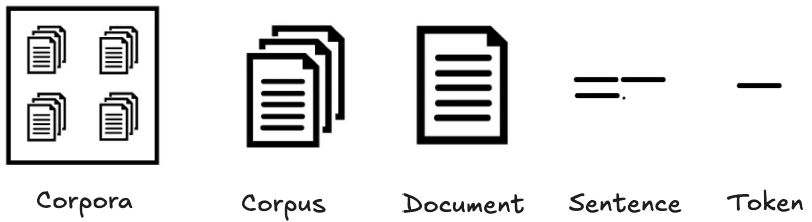
" width="1100" height="350"/>

1. Corpora <br>
: 여러개의 Corpus <br>
예) 다국어 번역 모델 Corpora [영어-한국어 번역 corpus, 한국어-일본어 번역 corpus, 등...]

2. Corpus <br>
: 자연어 문서들의 집합. 모델 학습용으로 수집된 텍스트 데이터 전체. <br>
예) 뉴스 기사 모음, 나무위키 데이터 모음, SNS 글 모음 <br>
⚠️ 단순히 텍스트의 모음이 아니라 품사 태그가 붙거나 텍스트에 라벨이 붙은 데이터도 전부 corpus라 부름 <br>
(raw corpus, annotated corpus, cleaned corpus 등..)

3. Document <br>
: Corpus를 구성하는 개별 문서. <br>
예) 뉴스 기사 하나, 나무위키 검색으로 보이는 페이지 하나, SNS 게시글 하나 <br>

4. Sentence <br> 
: Corpus를 구성하는 개별 문장. <br> 
  분석 목적에 따라 텍스트를 Document 대신 Sentence 단위로 지정하기도 함 <br> 
예) 두 문장의 유사도 분석이 필요한 경우

5. Token <br>
: 문장에서 의미 있는 최소 단위의 단어. <br>
예) "나는 비빔 인간입니다" -> 나, 비빔, 인간, 입니다 또는 나는, 비빔, 인간입니다 등...  <br>
⚠️ 토큰화는 목적에 따라 달라질 수 있음 

## Bag of Words 

> 문장을 단어의 집합(가방)으로 보고, 순서와 상관 없이 등장 횟수만 고려하는 방식 <br>
> 단어 목록을 만들고 이를 기반으로 문장을 벡터화 하는 과정까지 포함한다

### ✅ 특징 

#### ① 간단하고 빠른 처리가 가능 
#### ② 희소(sparse) 벡터가 만들어짐 
#### ③ 문맥을 고려하지 않음

In [132]:
from konlpy.tag import Mecab
from sklearn.feature_extraction.text import CountVectorizer

In [134]:
corpus1 = ["나는 비빔 인간입니다.", "나는 비빔밥을 좋아합니다.", "저는 파스타를 좋아합니다."]
corpus2 = ["오늘 날씨 매우 매우 좋다", "내일은 비 온다", "나는 날씨가 싫다"]

형태소 분석기 -> tokenizer로 부르고 사용

In [142]:
def okt_tokenizer(text):
    return okt.morphs(text)

def mecab_tokenizer(text):
    return mecab.morphs(text)

def custom_preprocessor(text):
    return text.replace('.', '')

korean_stopwords = ['는', '을', '를', '이', '가', '저는', '나는', '입니다', '합니다']

# 처리 순서 1. preprocessor 2. tokenizer 3. 불용어 처리 4. ngram 적용 5. 단어 빈도 계산 및 제거 6. 벡터 생성
vectorizer = CountVectorizer(tokenizer=okt_tokenizer,  # 사용자 지정 토크나이저 
                             stop_words=korean_stopwords, # 불용어 지정 
                             ngram_range=(1,2),  # n개 부터 m개 까지의 단어 묶음으로 만들기 -> 단어 사이의 문맥과 조합된 의미 반영을 위해
                             max_features=20, # 가장 많이 등장한 단어 개수 지정 
                             min_df=1, # 최소 1개 문서에 등장한 단어만 사용 
                             max_df=0.8, # n% 이상 문서에 등장하면 제외     = 너무 많이 등장하면 필수이지만 무의미한 단어일 수 있음
                             lowercase=False, # 한글에는 적용 X 
                             preprocessor=custom_preprocessor,
                             token_pattern='(?u)\\b\\w\\w+\\b') # 여기에 쓰인 정규식 패턴으로 토큰을 분리 (기본값)
                             # (?u) -> 유니코드 모드(한글을 포함한 문자도 글자로 인식 할 수 있게 해줌)
                             # \b -> 띄어쓰기를 기준으로 단어의 시작 혹은 끝으로 인식 
                             # \w -> 글자 하나 (한글, 영어, 숫자, 밑줄 중 하나)
                             # \w\w+ -> 두 글자 이상 
                             # 사용자 지정 토크나이저를 사용하면 정규식의 기본값이 미적용 된다는 경고문이 뜰 수 있음

In [143]:
data = vectorizer.fit_transform(corpus1)

d:\anaconda\envs\tf\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
d:\anaconda\envs\tf\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['나', '저'] not in stop_words.
  warnings.warn(


In [149]:
data

<3x13 sparse matrix of type '<class 'numpy.int64'>'
	with 15 stored elements in Compressed Sparse Row format>

#### ✅ Lazy Evaluation vs Eager Evaluation 

- Lazy Evaluation: 값을 지금 바로 계산하지 않고, 필요할 때마다 한 개씩 계산해서 리턴하는 방식 <br> 
- Eager Evaluation: 코드가 실행되면 바로 값을 만들어서 전체를 메모리에 저장하여 연산하는 방식  

### 네이버 영화 리뷰 긍정/부정 분석 

In [ ]:
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from konlpy.tag import Mecab
import re 

# 1. 데이터 불러오기
dataset = load_dataset('nsmc', trust_remote_code=True) 

### TF-IDF

> Term Frequency - Inverse Document Frequency의 약자로, <br> 
> 한 문서 안에서 단어가 몇번 나왔는지, 여러 문서 중 이 단어가 얼마나 희귀한지를 고려하여 데이터를 벡터화함 <br> 
> 흔한 단어는 가중치를 낮게, 자주 등장하는 단어는 가중치를 높게 

<img src="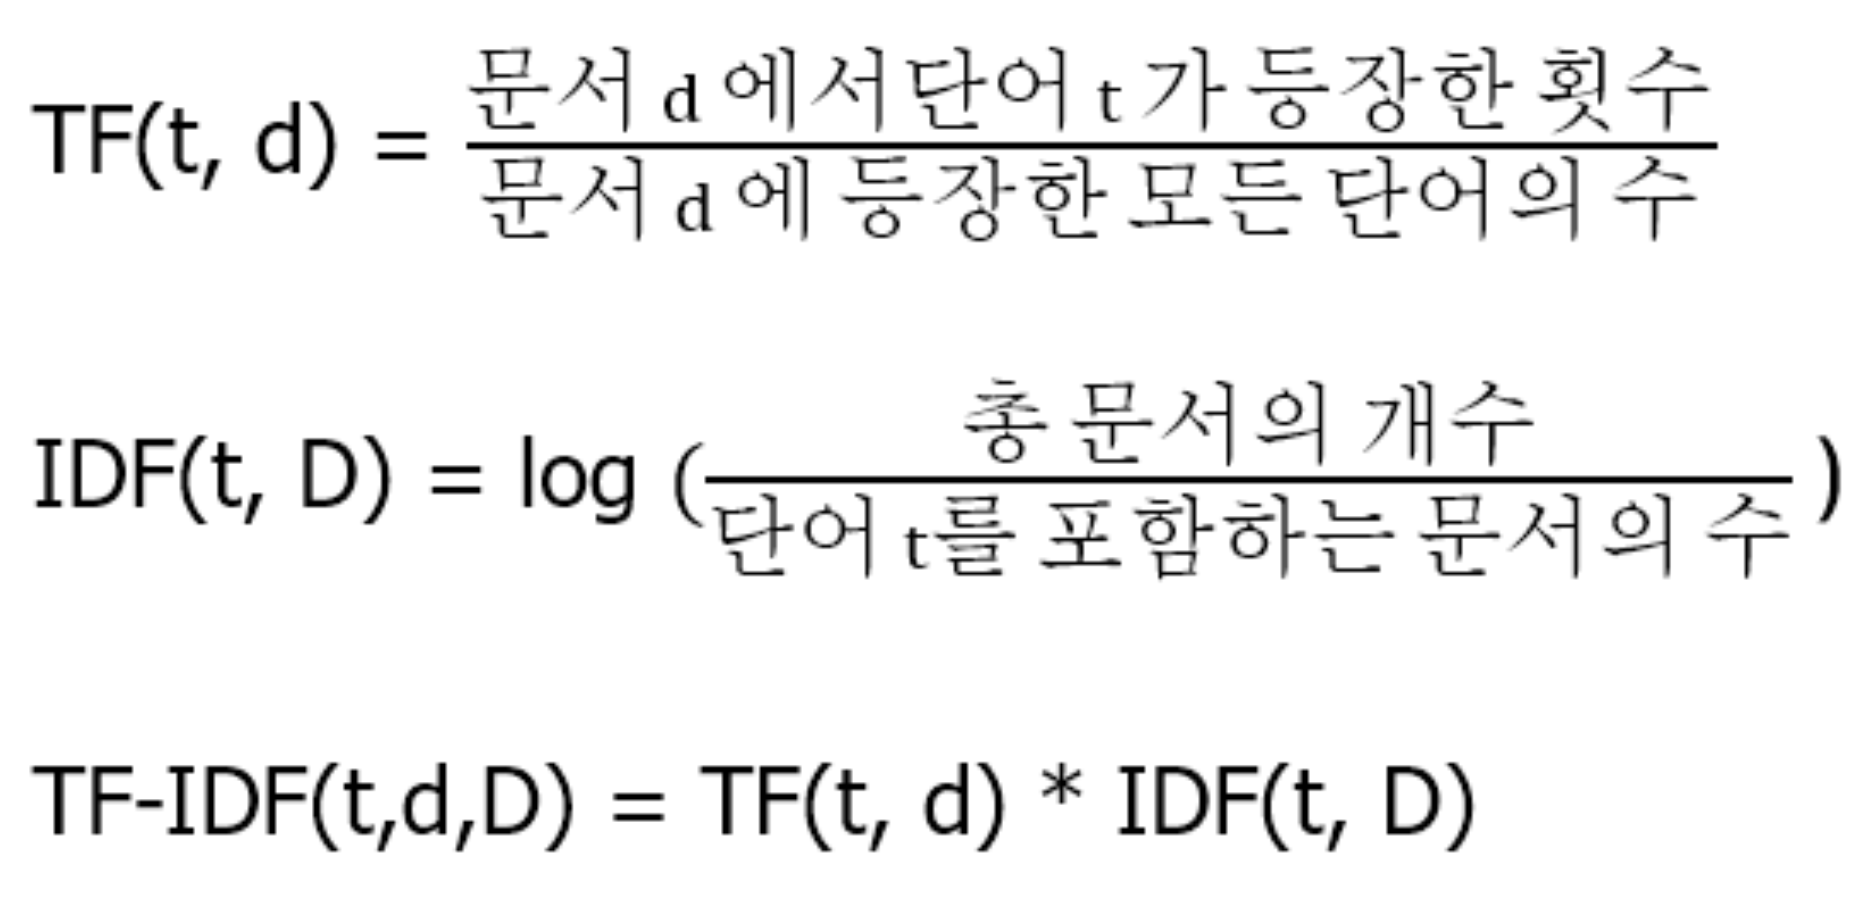
" width="680" height="350"/>

### ✅ 특징 

#### ① 단순히 단어의 빈도 뿐만 아니라 전체 문서에서 얼마나 희귀한지도 반영함 <br>
 -> 정보량에 높은 가중치를 줌 (the, a, 은, 는, 이, 가 같이 빈번한 단어는 중요도를 낮게 봄)
#### ② 단어의 등장 위치는 고려하지 않음  
#### ③ 희소(sparse) 벡터가 만들어짐 

### 시각화

# <a id='six'>6️⃣ 분산표현과 신경망</a><br>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### 단어간의 유사성을 표현하는 방법

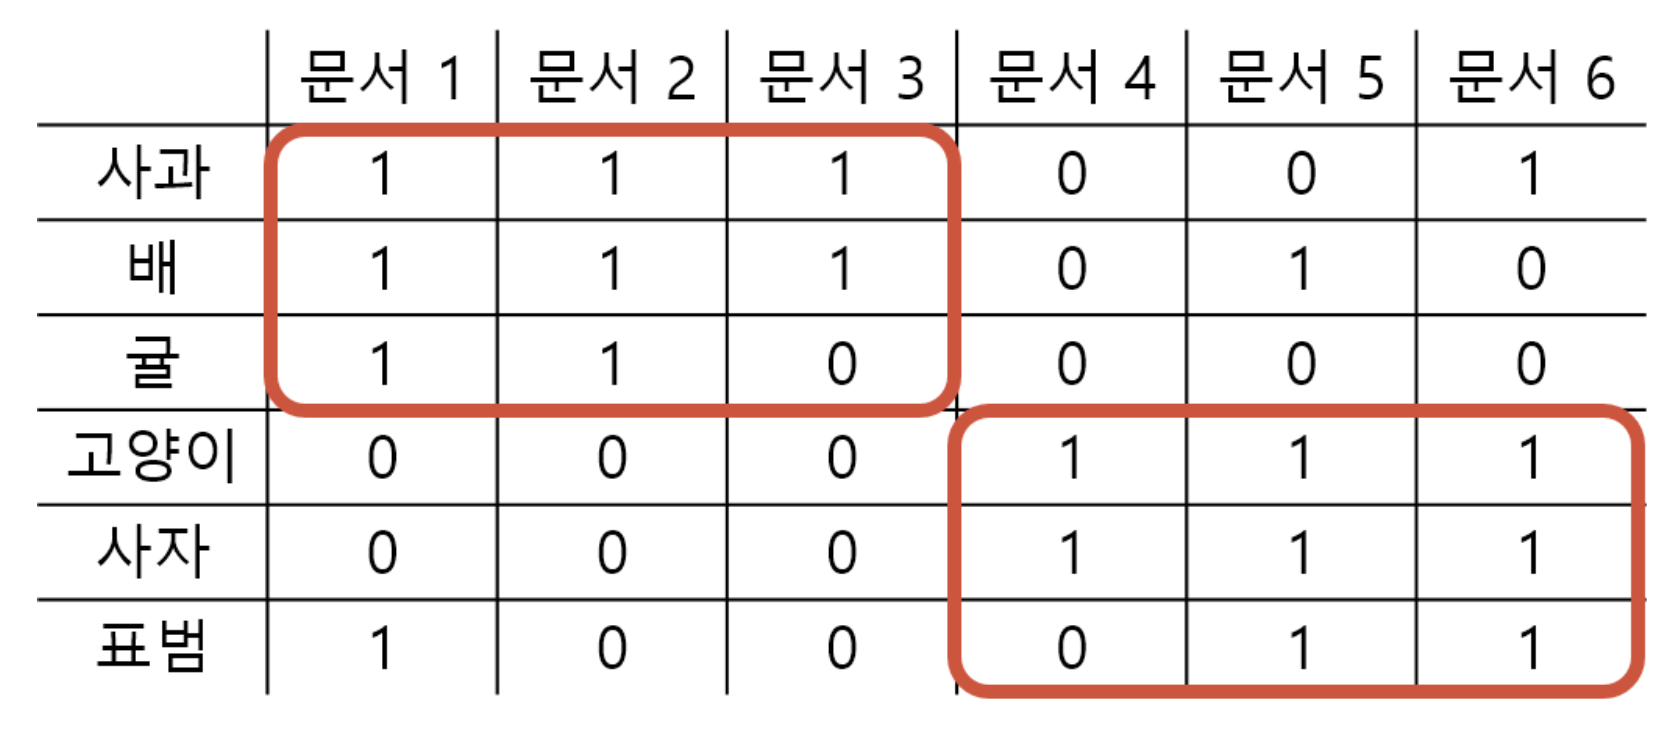

- 위 방식은 여러 문서가 있을 때 단어의 빈도를 통해 단어간의 유사성을 표현할 수는 있음 
- 하지만, 단어의 유무로 벡터를 표현하기 때문에 벡터 자체가 단어의 의미를 내포하고 있지는 않음

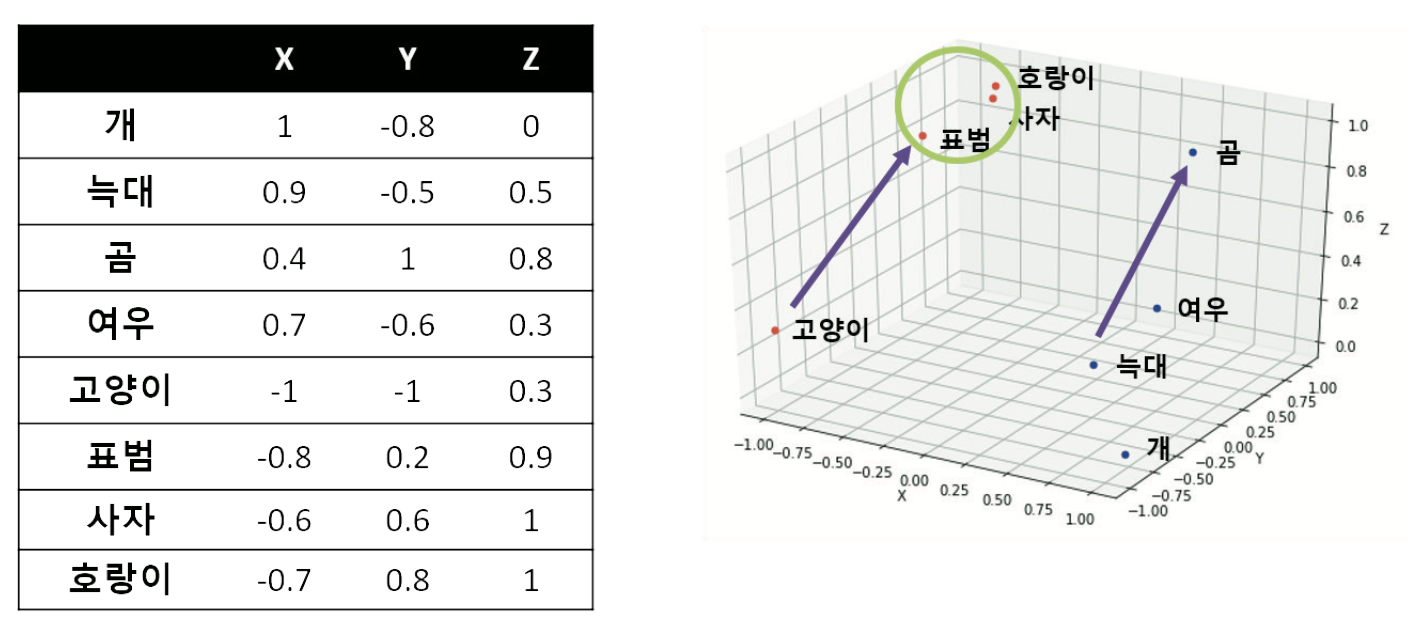

- 각 단어가 3차원 좌표 상의 한 점으로 표현 
- 좌표 상의 단순한 숫자(벡터)가 다른 단어와 함께 보면 즉, 문맥으로 보면 의미를 가짐 
- 비슷한 문맥에서 사용된 단어들일수록 비슷한 벡터 값을 가지게 됨

#### ✅ Word Embedding이란, 비슷한 의미를 가진 단어들을 비슷한 숫자 벡터로 표현한 결과물. 
-> 이 결과물은 많은 텍스트 데이터를 통해 학습하여 만들어진다

### 🧐 어떻게 학습해야 Word Embedding을 만들 수 있는 걸까?

## Word2Vec

> 기존의 희소 벡터 방식의 한계를 극복하기 위해 만들어진 자연어 처리 기법 <br> 
> "비슷한 문맥에서 쓰이는 단어는 비슷한 의미를 가진다"는 분포 가설(Distributional Hypothesis)을 가정함 <br> 
> 주변 단어로 부터 중심 단어를 예측 하거나, 중심 단어로 부터 주변 단어를 예측하는 방식을 통해 단어를 의미 있는 벡터로 표현한다

<img src="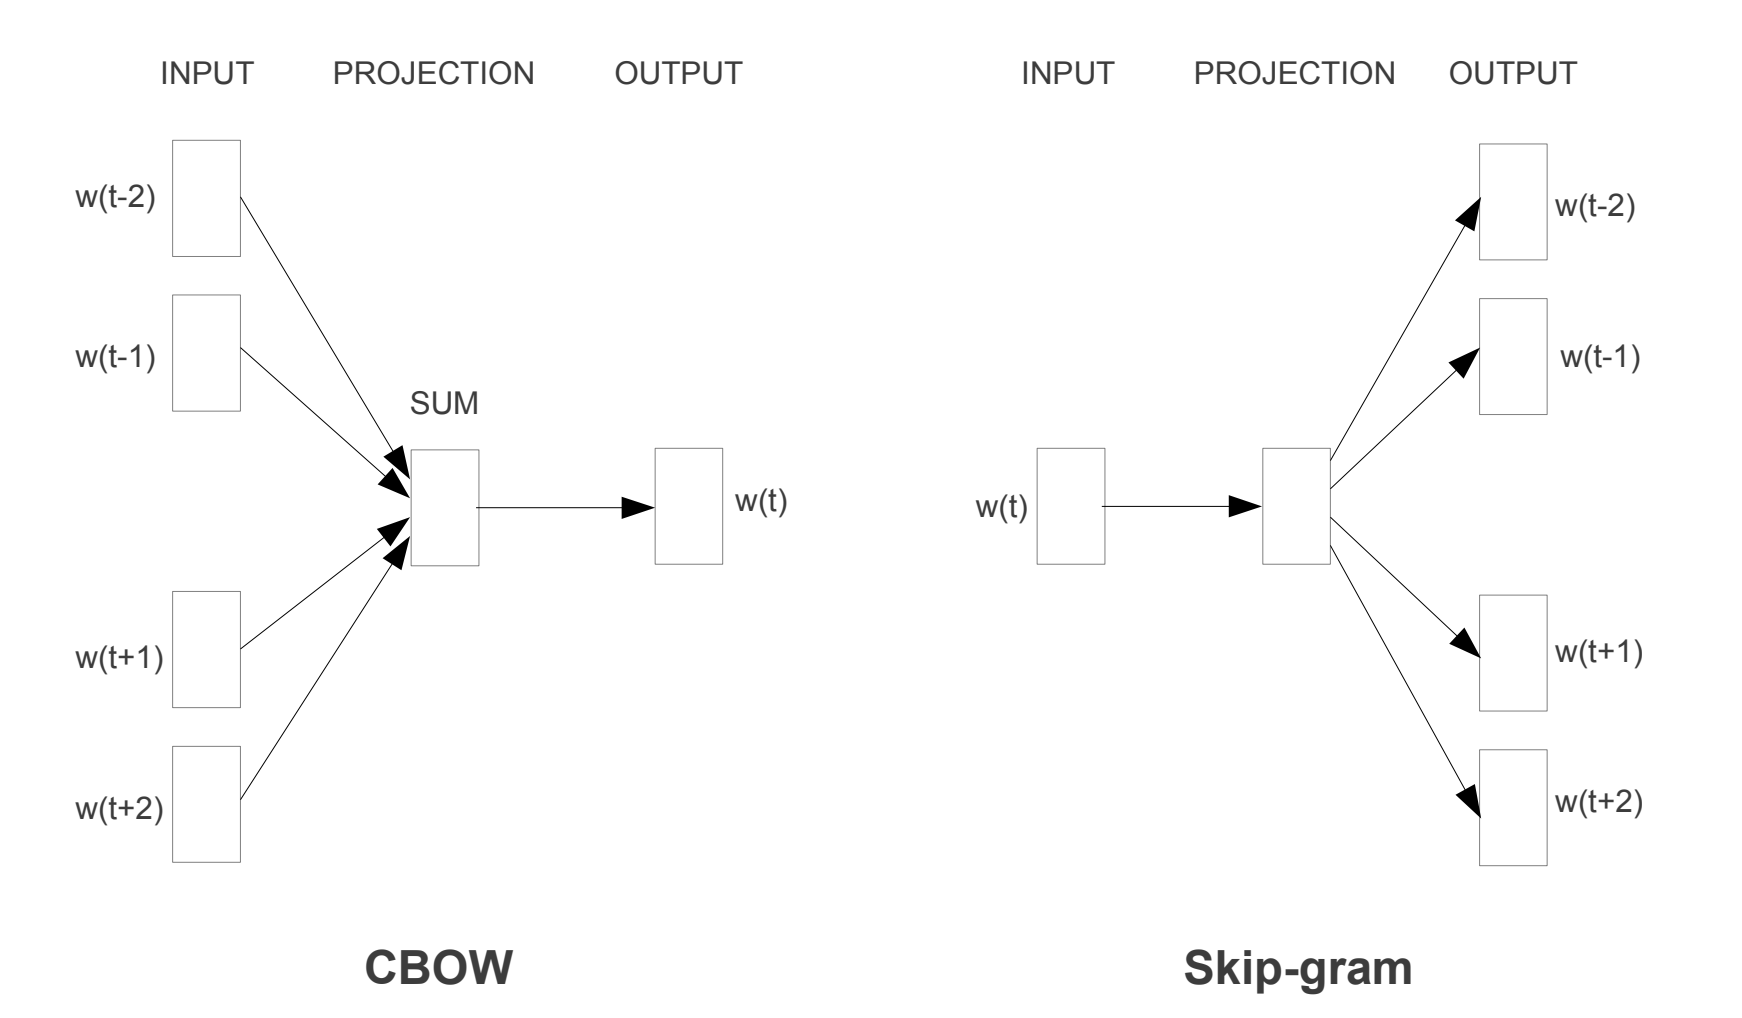
" width="650" height="400"/>

### CBOW (Continuous bag-of-word model)

> 앞 뒤 문맥을 보고 중심 단어를 유추하는 학습 방식

### Skip-gram

> CBOW와 반대. 중심 단어로 부터 이전 단어와 이후 단어를 유추하는 학습 방식

In [ ]:
from gensim.models import Word2Vec

# 모델 학습
model = Word2Vec(
    tokenized_corpus,  # 토큰화된 corpus로 입력값을 넣으면 내부적으로 입력-정답쌍을 만들어 연산을 함 
    vector_size=50,   # 임베딩 벡터 차원
    window=2,          # 좌우 몇개 단어를 문맥으로 볼지 결정 (ex) window=2, skip-gram: 중심 1개 단어로 주변 4개 예측 / CBOW: 주변 4개로 중심 1개 예측 )
    min_count=5,       # 최소 등장 빈도 (1 이상만 학습)
    workers=2,         # 멀티코어 처리 수
    epochs=10,         # 작은 말뭉치 (1 ~ 10만: 10 ~ 20 epochs) / 중간 규모 (100만: 5 ~ 10 epochs) / 대규모 (1000만 이상 3 ~ 5 epochs)
    sg=1              # 1 = Skip-Gram, 0 = CBOW
)

### Embedding vector 시각화